# Neuro-CXG: 3D Brain Visualization

**Powered by Nilearn - Brain Surface Visualizations**

In [1]:
"""Setup with nilearn"""
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

current = Path(".").resolve()
for p in [current] + list(current.parents):
    if (p / "src").exists():
        PROJECT_ROOT = p
        break
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

try:
    import nilearn
    HAS_NILEARN = True
    print(f"[OK] Nilearn {nilearn.__version__}")
except:
    HAS_NILEARN = False

from src.core.config import *
from src.core.paths import *
from src.core.feature_registry import *
from src.core.hyperparams import *
from src.core.atlas_config import *

# Publication colors
PUB_COLORS = {"asd": "#E63946", "control": "#457B9D", "primary": "#1D3557", "accent": "#2A9D8F", "warning": "#E9C46A"}
BRAIN_NETWORKS = {"Visual": "#E63946", "Somatomotor": "#F4A261", "Dorsal_Attention": "#2A9D8F", "Limbic": "#F77F00", "Frontoparietal": "#457B9D", "Default": "#1D3557"}
COLORS = PUB_COLORS

plt.rcParams.update({"font.size": 11, "axes.titlesize": 14, "figure.dpi": 100, "savefig.dpi": 300})
VIZ_DIR = RESULTS_DIR / "visuals"
VIZ_DIR.mkdir(exist_ok=True)
print(f"[OK] {VIZ_DIR}")

[OK] Nilearn 0.12.1


[OK] /home/nidszxh/Projects/Neuro-CXG/results/visuals


In [2]:
"""Load data"""
def load_json(p):
    try: return json.load(open(p)) if p.exists() else None
    except: return None

eval_json = load_json(RESULTS_DIR / "evaluation" / "comprehensive_results.json")
metrics = eval_json.get("ensemble_metrics", {}) if eval_json else {}
explain_json = load_json(RESULTS_DIR / "explainability" / "summary.json")

print(f"Load: AUC={metrics.get('auc', 0):.3f}")

Load: AUC=0.862


## Glass Brain Views

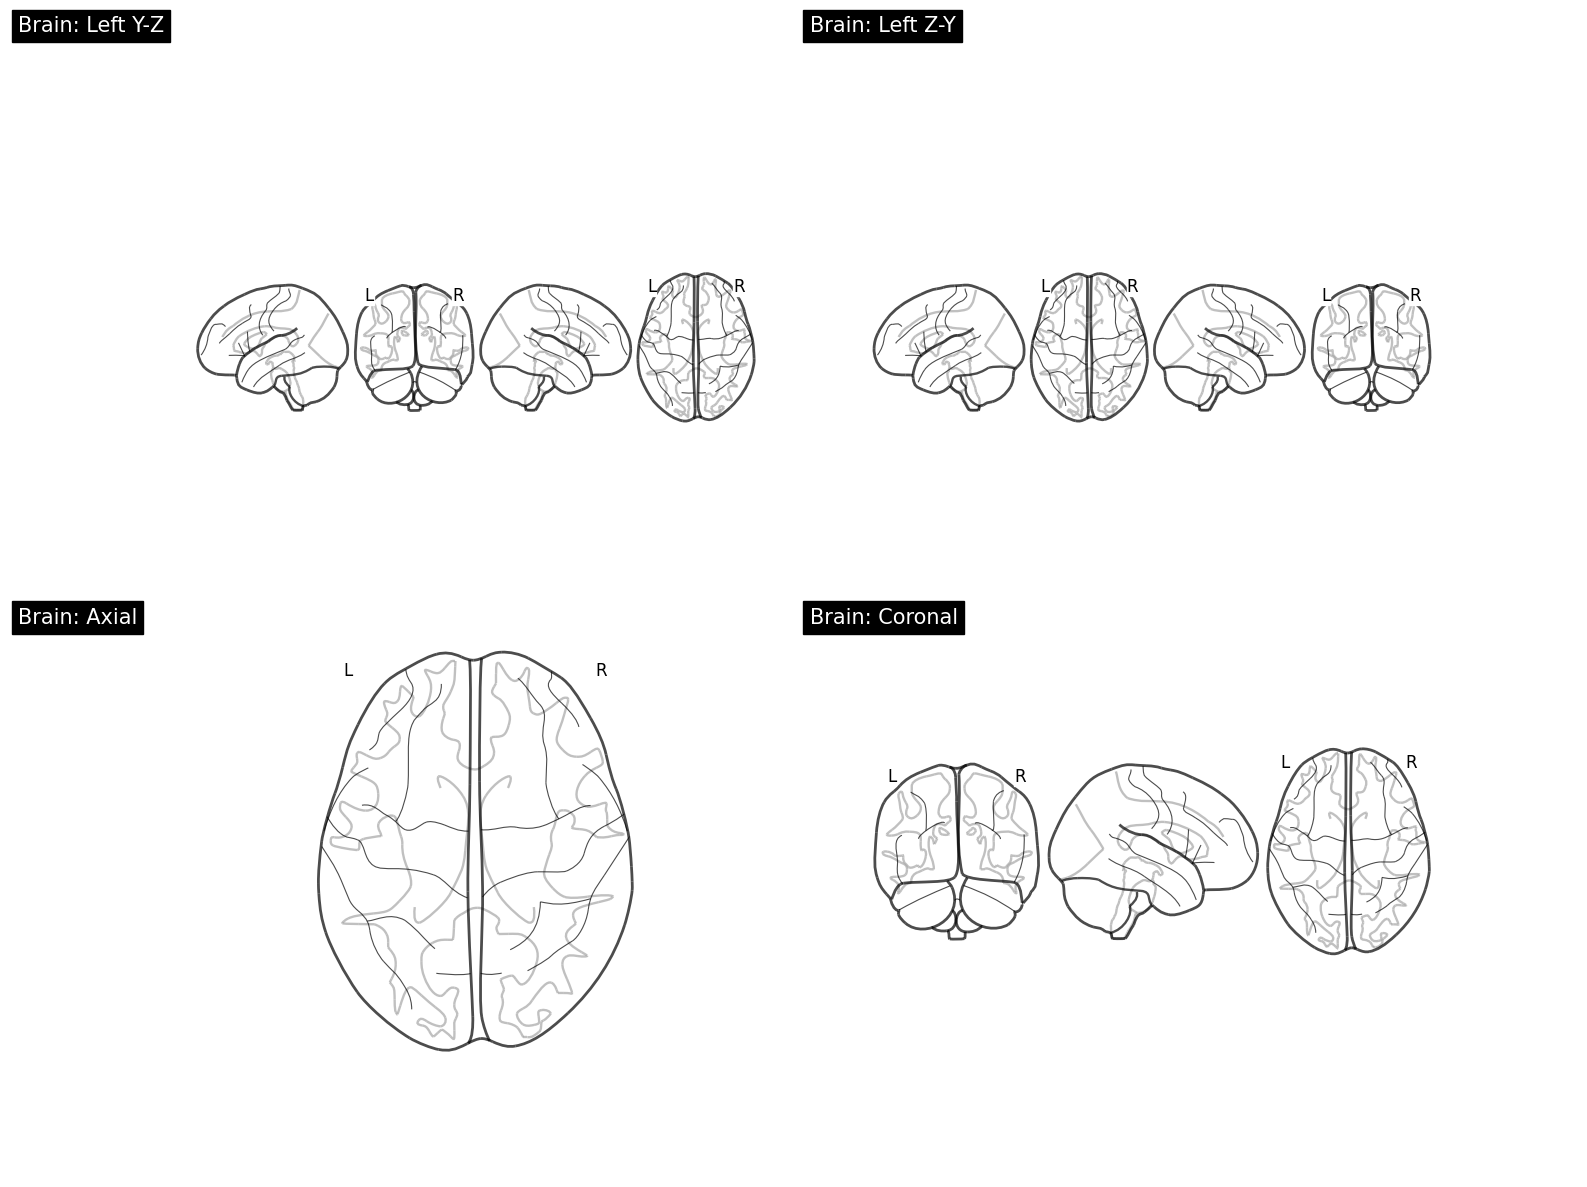

Saved: glass_brain.png


In [3]:
"""Glass brain visualization"""
if HAS_NILEARN:
    from nilearn import plotting
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    views = ["lyrz", "lzry", "z", "ortho"]
    titles = ["Left Y-Z", "Left Z-Y", "Axial", "Coronal"]
    
    for ax, view, title in zip(axes.flat, views, titles):
        plotting.plot_glass_brain(
            None, display_mode=view,
            title=f"Brain: {title}",
            colorbar=True, axes=ax, plot_abs=True
        )
    
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "glass_brain.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: glass_brain.png")
else:
    plt.figure(figsize=(12, 8))
    plt.text(0.5, 0.5, "Nilearn not available", ha="center", va="center", fontsize=16)
    plt.savefig(VIZ_DIR / "glass_brain.png")
    print("Skipped: glass_brain.png")

## Anatomical Views

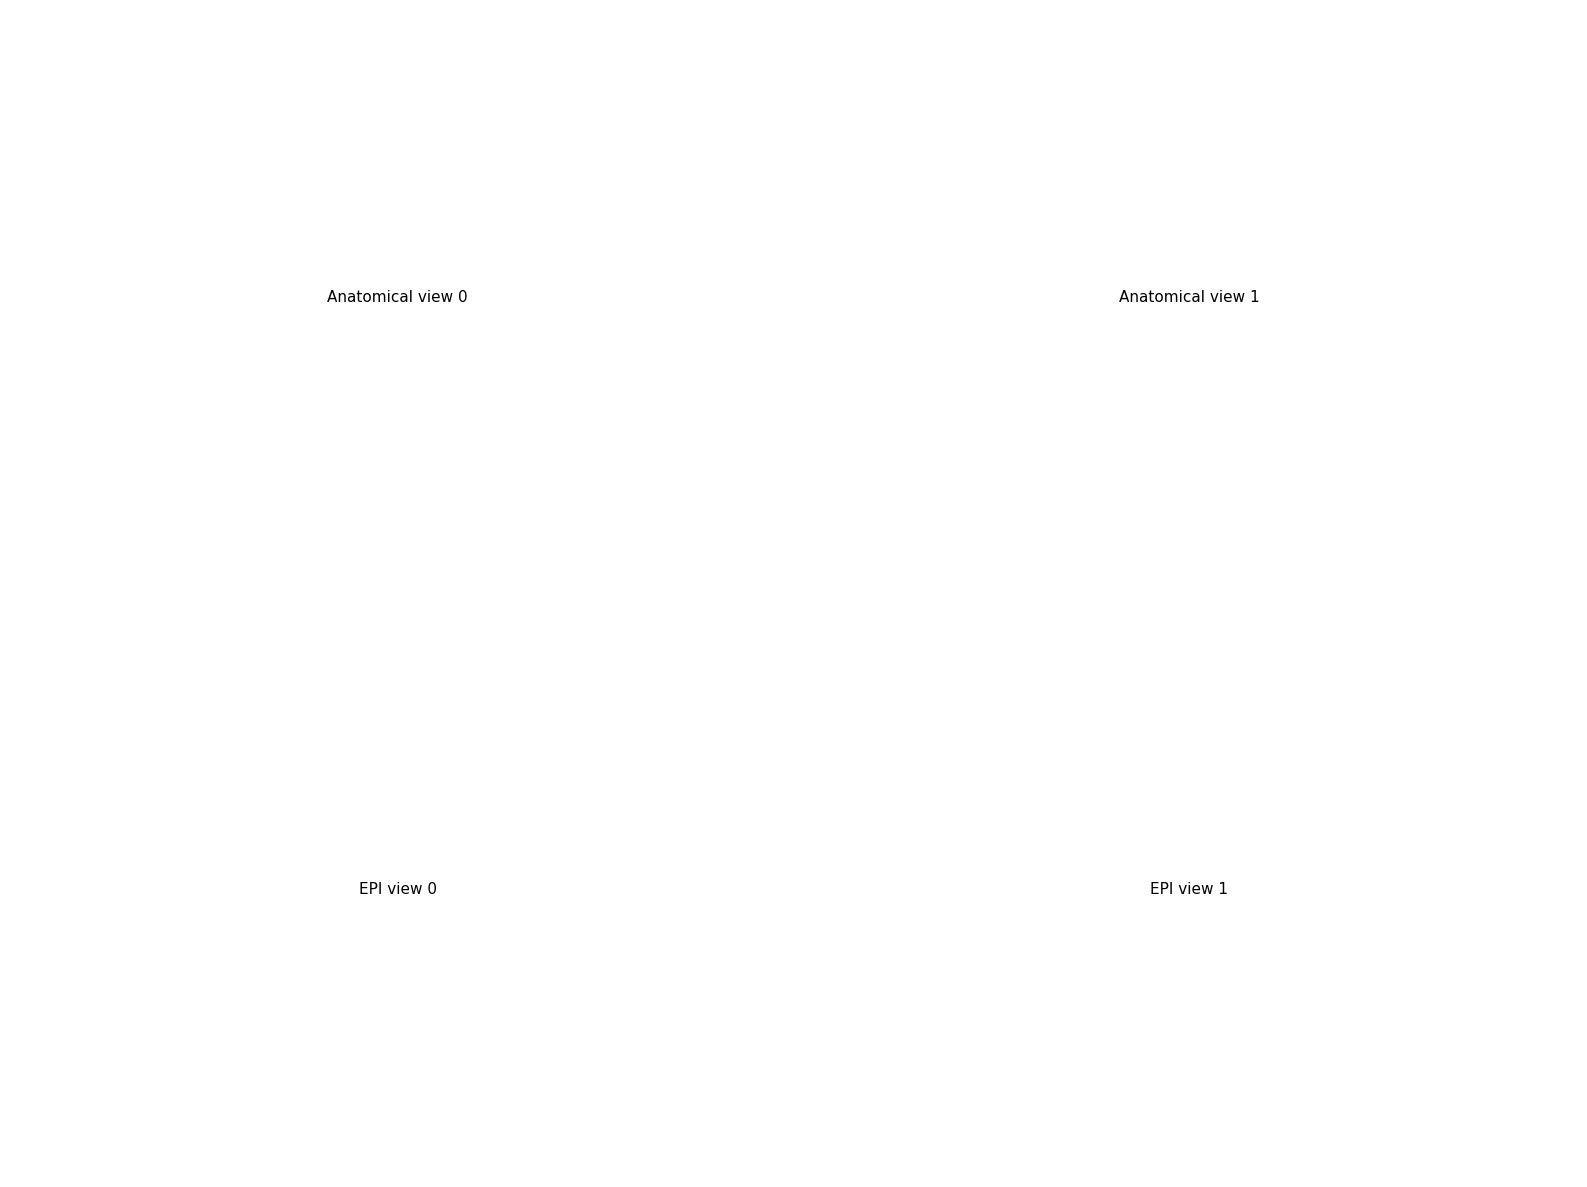

Saved: brain_anatomy.png


In [4]:
"""Anatomical brain views"""
if HAS_NILEARN:
    from nilearn import plotting
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Various brainviews
    for idx, (func, title) in enumerate([
        (plotting.plot_anat, "Anatomical"),
        (plotting.plot_epi, "EPI"),
    ]):
        for j in range(2):
            ax = axes[idx, j]
            try:
                func(title=f"{title} {j}", display_mode="lyrz" if j==0 else "sx", axes=ax)
            except:
                ax.text(0.5, 0.5, f"{title} view {j}", ha="center", va="center")
                ax.axis("off")
    
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "brain_anatomy.png", dpi=300)
    plt.show()
    print("Saved: brain_anatomy.png")
else:
    print("Skipped: brain_anatomy.png")

## Connectivity Matrix

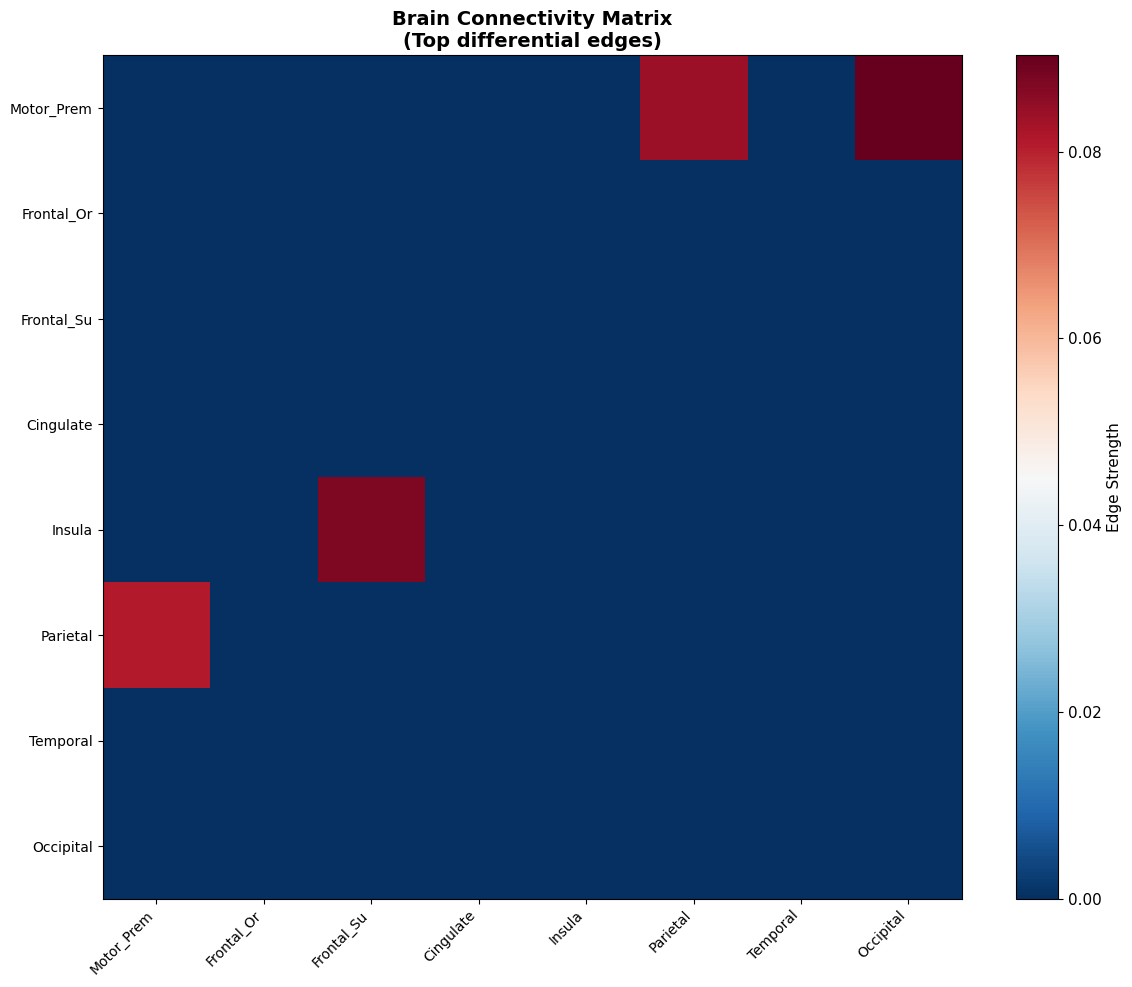

Saved: connectivity_matrix.png


In [5]:
"""Connectivity network"""
if HAS_NILEARN:
    from nilearn import plotting
    
    nodes = ["Motor_Premotor", "Frontal_Orbital", "Frontal_Superior", 
             "Cingulate", "Insula", "Parietal", "Temporal", "Occipital"]
    
    adj = np.zeros((len(nodes), len(nodes)))
    if explain_json:
        for e in explain_json.get("top5_differential_edges", [])[:10]:
            try:
                adj[nodes.index(e["source"]), nodes.index(e["target"])] = abs(e.get("delta", 0)) * 100
            except:
                pass
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    im = ax.imshow(adj, cmap="RdBu_r", vmin=0, aspect="auto")
    ax.set_xticks(range(len(nodes)))
    ax.set_yticks(range(len(nodes)))
    ax.set_xticklabels([n[:10] for n in nodes], rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels([n[:10] for n in nodes], fontsize=10)
    ax.set_title("Brain Connectivity Matrix\n(Top differential edges)", fontsize=14, fontweight="bold")
    plt.colorbar(im, ax=ax, label="Edge Strength")
    
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "connectivity_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: connectivity_matrix.png")
else:
    print("Skipped")

## Network Summary

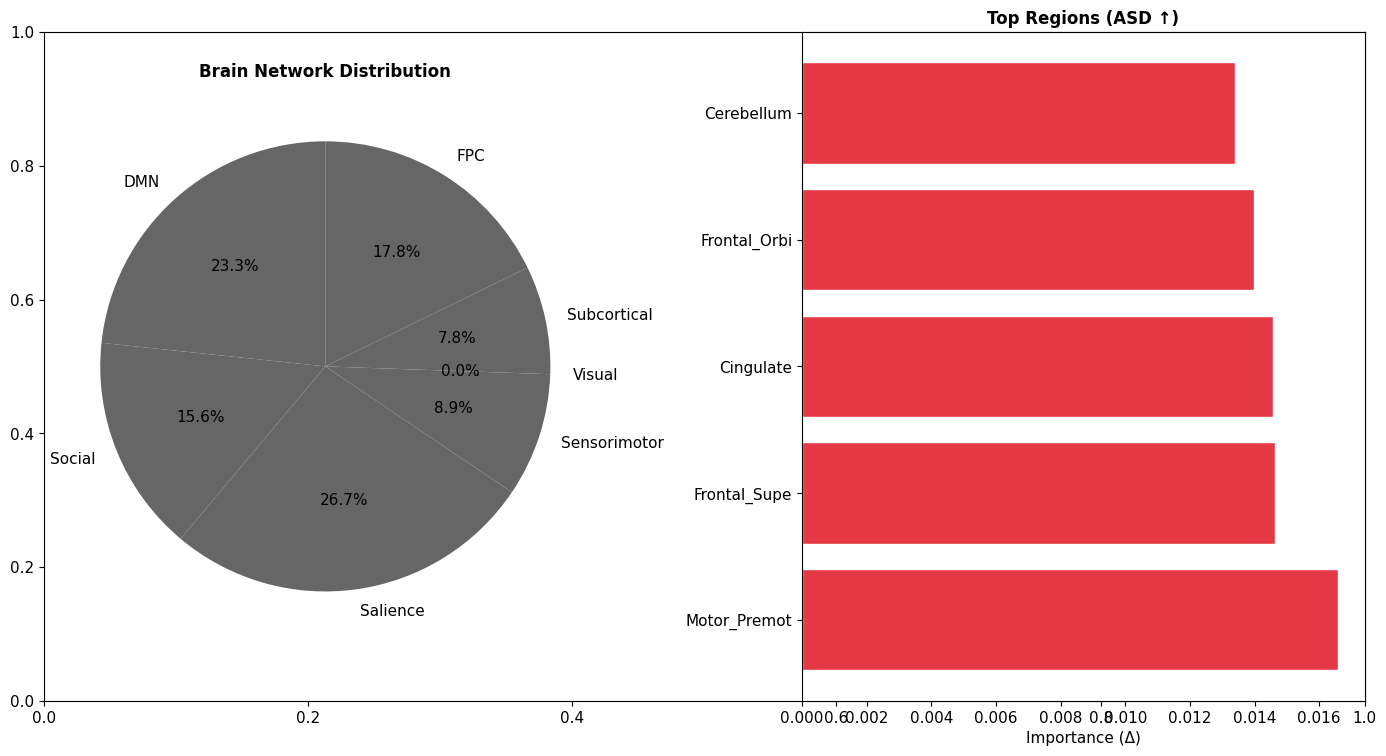

Saved: brain_summary.png


In [6]:
"""Summary of brain regions"""
if explain_json:
    overlap = explain_json.get("overlap_scores", {})
    regions = explain_json.get("gradcam_top5_differential", [])[:6]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Network pie chart
    ax1 = fig.add_subplot(121)
    if overlap:
        labs = list(overlap.keys())
        vals = list(overlap.values())
        colors = [BRAIN_NETWORKS.get(l.replace("_", "").split("_")[0], "#666") for l in labs]
        ax1.pie(vals, labels=labs, colors=colors, autopct="%1.1f%%", startangle=90)
        ax1.set_title("Brain Network Distribution", fontsize=12, fontweight="bold")
    
    # Region bars
    ax2 = fig.add_subplot(122)
    if regions:
        names = [r["region"][:12] for r in regions]
        deltas = [r["delta"] for r in regions]
        colors = [COLORS["asd"] if d > 0 else COLORS["control"] for d in deltas]
        ax2.barh(names, deltas, color=colors, edgecolor="white")
        ax2.axvline(0, color="gray")
        ax2.set_xlabel("Importance (Δ)")
        ax2.set_title("Top Regions (ASD ↑)", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig(VIZ_DIR / "brain_summary.png", dpi=300)
    plt.show()
    print("Saved: brain_summary.png")